# COCO Dining-6 Concept Leakage Figures

This notebook compares the learned non-orthogonalized CAVs at alpha = 0 with their orthogonalized counterparts at alpha = 0.1, 1, and 10. It reads only the saved experiment outputs; access to the COCO images or model checkpoint is not required.


In [1]:
from pathlib import Path
import re
import warnings
from typing import Sequence

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})


## Configuration and data loading

The configuration below selects one downloaded result family. Change MODEL_LAYER to vgg16_ssd_coco_features.28 to inspect the second downloaded layer, or PRIMARY_CAV_TYPE to change the method used in the detailed heatmaps and qualitative panels.


In [2]:
def _find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "concept_leakage").exists():
            return candidate
    raise FileNotFoundError("Could not locate results/concept_leakage from the current directory.")


PROJECT_ROOT = _find_project_root()
RESULTS_ROOT = PROJECT_ROOT / "results" / "concept_leakage"
DATASET_PRESET = "coco_dining6"
MODEL_LAYER = "vgg16_ssd_coco_features.29"
RUN_GROUP = "epochs200_train10000_subsetseed42"
SEED_DIR = "seed42"
LEARNING_RATE = 0.0001

CAV_TYPES = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "ridge_cav")
ALPHAS = (0.0, 0.1, 1.0, 10.0)
PRIMARY_CAV_TYPE = "pattern_cav"
CONCEPT_ORDER = ("cup", "fork", "knife", "spoon", "bowl", "dining table")

SAVE_FIGURES = False
FIGURE_ROOT = PROJECT_ROOT / "media" / "concept_leakage"

CAV_LABELS = {
    "pattern_cav": "Pattern",
    "multi_cav": "Multi",
    "svm_cav": "SVM",
    "log_cav": "Logistic",
    "ridge_cav": "Ridge",
}
CAV_COLORS = {
    "pattern_cav": "#3568A8",
    "multi_cav": "#D17C30",
    "svm_cav": "#758C45",
    "log_cav": "#B55C80",
    "ridge_cav": "#C19A28",
}
ALPHA_MARKERS = {0.0: "o", 0.1: "s", 1.0: "^", 10.0: "D"}
ALPHA_COLORS = {0.0: "#4A4A4A", 0.1: "#A9C5E8", 1.0: "#4C83C3", 10.0: "#1F4F88"}


def alpha_label(alpha: float) -> str:
    return "alpha=0 (baseline)" if np.isclose(alpha, 0.0) else f"alpha={alpha:g}"


def finish_figure(fig: plt.Figure, filename: str) -> plt.Figure:
    if SAVE_FIGURES:
        FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_ROOT / f"{filename}.png", dpi=300, bbox_inches="tight")
        fig.savefig(FIGURE_ROOT / f"{filename}.pdf", bbox_inches="tight")
    plt.show()
    return fig


In [3]:
RUN_NAME_PATTERN = re.compile(r"^alpha(?P<alpha>[-+0-9.eE]+)_lr(?P<lr>[-+0-9.eE]+)$")


def discover_runs() -> pd.DataFrame:
    result_family = RESULTS_ROOT / DATASET_PRESET / MODEL_LAYER
    records = []
    pattern = f"*/{RUN_GROUP}/{SEED_DIR}/alpha*_lr*/config.yaml"
    for config_path in sorted(result_family.glob(pattern)):
        match = RUN_NAME_PATTERN.fullmatch(config_path.parent.name)
        if match is None:
            continue
        alpha = float(match.group("alpha"))
        learning_rate = float(match.group("lr"))
        if not np.isclose(learning_rate, LEARNING_RATE):
            continue
        cav_type = config_path.relative_to(result_family).parts[0]
        if cav_type not in CAV_TYPES:
            continue

        metrics_dir = config_path.parent / "metrics"
        required = (
            "localization_per_sample.csv",
            "localization_summary.csv",
            "leakage_per_sample.csv",
            "leakage_matrix.csv",
            "leakage_counts.csv",
        )
        missing = [name for name in required if not (metrics_dir / name).exists()]
        if missing:
            warnings.warn(f"Skipping incomplete run {config_path.parent}: {missing}")
            continue
        records.append({
            "cav_type": cav_type,
            "alpha": alpha,
            "learning_rate": learning_rate,
            "run_dir": config_path.parent,
        })

    runs = pd.DataFrame(records)
    if runs.empty:
        available = sorted(path.parent.name for path in RESULTS_ROOT.glob("**/config.yaml"))
        raise FileNotFoundError(
            f"No complete runs found below {result_family}. "
            f"Available run names include: {available[:8]}"
        )

    duplicates = runs.duplicated(["cav_type", "alpha"], keep=False)
    if duplicates.any():
        raise ValueError("More than one run matches a CAV/alpha setting:\n" + str(runs.loc[duplicates]))

    cav_order = {name: index for index, name in enumerate(CAV_TYPES)}
    alpha_order = {value: index for index, value in enumerate(ALPHAS)}
    runs["_cav_order"] = runs["cav_type"].map(cav_order)
    runs["_alpha_order"] = runs["alpha"].map(alpha_order)
    runs = runs.sort_values(["_cav_order", "_alpha_order"])
    return runs.drop(columns=["_cav_order", "_alpha_order"]).reset_index(drop=True)


RUNS = discover_runs()
RUN_INDEX = {(row.cav_type, float(row.alpha)): Path(row.run_dir) for row in RUNS.itertuples()}


def get_run_dir(cav_type: str, alpha: float) -> Path:
    key = (cav_type, float(alpha))
    if key not in RUN_INDEX:
        raise KeyError(f"Run not available for {cav_type}, alpha={alpha:g}")
    return RUN_INDEX[key]


def load_square_csv(cav_type: str, alpha: float, filename: str) -> pd.DataFrame:
    path = get_run_dir(cav_type, alpha) / "metrics" / filename
    frame = pd.read_csv(path, index_col="source_concept")
    return frame.reindex(index=CONCEPT_ORDER, columns=CONCEPT_ORDER)


localization_frames = []
run_summary_rows = []
for run in RUNS.itertuples():
    run_dir = Path(run.run_dir)
    localization = pd.read_csv(run_dir / "metrics" / "localization_summary.csv")
    localization["cav_type"] = run.cav_type
    localization["alpha"] = float(run.alpha)
    localization_frames.append(localization)

    leakage_matrix = load_square_csv(run.cav_type, run.alpha, "leakage_matrix.csv").astype(float)
    leakage_counts = load_square_csv(run.cav_type, run.alpha, "leakage_counts.csv").fillna(0).astype(int)
    off_diagonal = ~np.eye(len(CONCEPT_ORDER), dtype=bool)
    supported = (
        off_diagonal
        & leakage_counts.to_numpy().astype(bool)
        & np.isfinite(leakage_matrix.to_numpy())
    )

    def macro_metric(metric: str) -> float:
        values = localization.loc[localization["metric"].eq(metric), "mean"].astype(float)
        return float(values.mean())

    run_summary_rows.append({
        "cav_type": run.cav_type,
        "alpha": float(run.alpha),
        "target_relevance": macro_metric("target_relevance"),
        "pointing_game": macro_metric("pointing_game"),
        "iou": macro_metric("iou"),
        "intersection_over_gt": macro_metric("intersection_over_gt"),
        "off_diagonal_leakage": float(leakage_matrix.to_numpy()[supported].mean()),
        "supported_pairs": int(supported.sum()),
    })

LOCALIZATION_SUMMARY = pd.concat(localization_frames, ignore_index=True)
RUN_SUMMARY = pd.DataFrame(run_summary_rows)

expected = {(cav_type, alpha) for cav_type in CAV_TYPES for alpha in ALPHAS}
missing = sorted(expected - set(RUN_INDEX))
if missing:
    warnings.warn(f"Missing requested runs: {missing}")

print(f"Loaded {len(RUNS)} complete runs from {RESULTS_ROOT / DATASET_PRESET / MODEL_LAYER}")
RUNS[["cav_type", "alpha", "learning_rate"]]


Loaded 20 complete runs from /Users/erogullari/workspace/cav-disentanglement/results/concept_leakage/coco_dining6/vgg16_ssd_coco_features.29


,cav_type,alpha,learning_rate
0,pattern_cav,0.0,0.0001
1,pattern_cav,0.1,0.0001
2,pattern_cav,1.0,0.0001
3,pattern_cav,10.0,0.0001
4,multi_cav,0.0,0.0001
5,multi_cav,0.1,0.0001
6,multi_cav,1.0,0.0001
7,multi_cav,10.0,0.0001
8,svm_cav,0.0,0.0001
9,svm_cav,0.1,0.0001


## Figure 1 — Dining-6 co-occurrence matrix

This row-normalized heatmap estimates P(column concept | row concept) from the selected positive validation cohorts. It establishes the natural concept correlations before measuring CAV leakage. The counts are dataset properties and therefore do not change with alpha; the alpha = 0 run is used only as the source of the shared count matrix.


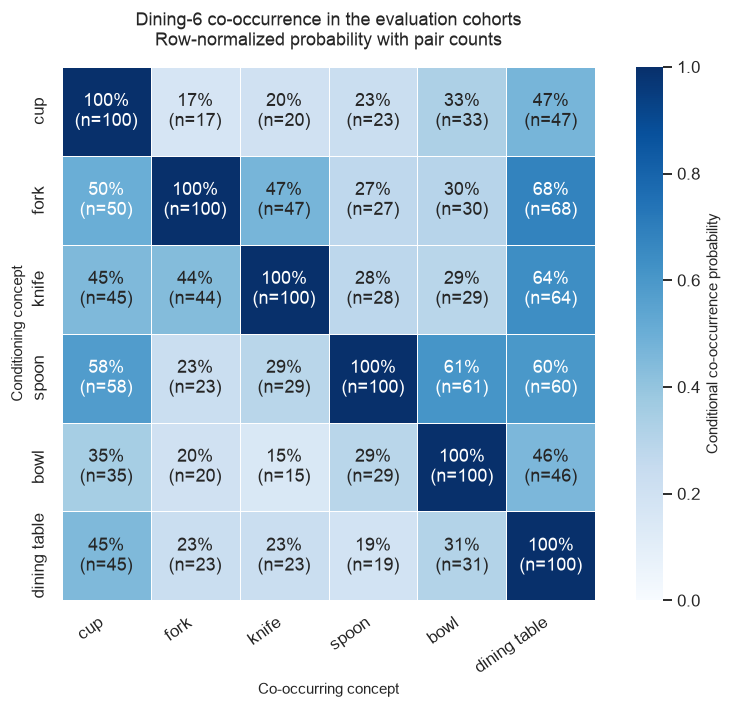

In [4]:
def plot_cooccurrence_matrix(
    cav_type: str = PRIMARY_CAV_TYPE,
    alpha: float = 0.0,
) -> pd.DataFrame:
    counts = load_square_csv(cav_type, alpha, "leakage_counts.csv").fillna(0).astype(int)
    row_totals = pd.Series(np.diag(counts), index=counts.index, dtype=float)
    if (row_totals <= 0).any():
        raise ValueError("Every source-concept cohort must have a positive diagonal count.")
    conditional = counts.div(row_totals, axis=0)

    annotations = np.empty(conditional.shape, dtype=object)
    for row in range(conditional.shape[0]):
        for column in range(conditional.shape[1]):
            annotations[row, column] = (
                f"{conditional.iat[row, column]:.0%}\n"
                f"(n={counts.iat[row, column]})"
            )

    fig, axis = plt.subplots(figsize=(8.2, 6.6))
    sns.heatmap(
        conditional,
        annot=annotations,
        fmt="",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"label": "Conditional co-occurrence probability"},
        ax=axis,
    )
    axis.set_title(
        "Dining-6 co-occurrence in the evaluation cohorts\n"
        "Row-normalized probability with pair counts",
        pad=14,
    )
    axis.set_xlabel("Co-occurring concept")
    axis.set_ylabel("Conditioning concept")
    axis.set_xticklabels(axis.get_xticklabels(), rotation=35, ha="right")
    fig.tight_layout()
    finish_figure(fig, f"figure_1_cooccurrence_{MODEL_LAYER}")
    return conditional


COOCCURRENCE = plot_cooccurrence_matrix()


## Figure 2 — Target-localization versus leakage Pareto plot

Each point is one CAV method and alpha setting. The x-axis is macro-average target relevance across Dining-6, while the y-axis is macro-average directed off-diagonal leakage across supported concept pairs. Better configurations move toward the lower-right: more relevance in the target mask and less relevance in exclusive distractor masks. Open circles denote the alpha = 0 baseline.


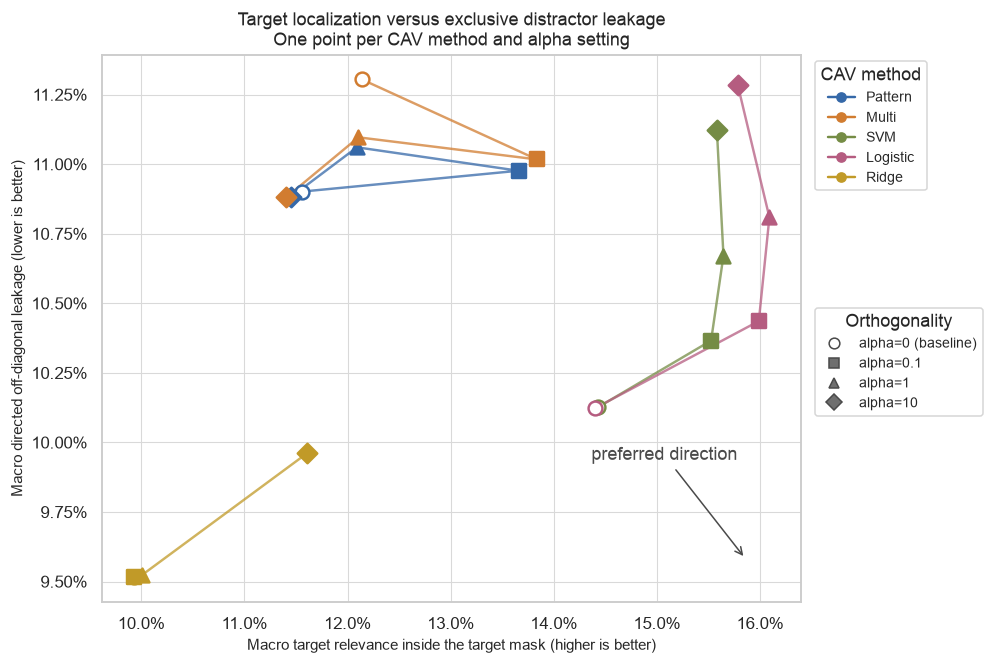

In [5]:
def plot_localization_leakage_pareto(
    summary: pd.DataFrame = RUN_SUMMARY,
) -> plt.Figure:
    fig, axis = plt.subplots(figsize=(9.2, 6.2))

    for cav_type in CAV_TYPES:
        series = summary.loc[summary["cav_type"].eq(cav_type)].copy()
        if series.empty:
            continue
        series["_order"] = series["alpha"].map(
            {alpha: index for index, alpha in enumerate(ALPHAS)}
        )
        series = series.sort_values("_order")
        color = CAV_COLORS[cav_type]
        axis.plot(
            series["target_relevance"],
            series["off_diagonal_leakage"],
            color=color,
            linewidth=1.6,
            alpha=0.75,
            zorder=2,
        )
        for row in series.itertuples():
            is_baseline = np.isclose(row.alpha, 0.0)
            axis.scatter(
                row.target_relevance,
                row.off_diagonal_leakage,
                marker=ALPHA_MARKERS[float(row.alpha)],
                s=82,
                facecolor="white" if is_baseline else color,
                edgecolor=color,
                linewidth=1.6,
                zorder=3,
            )

    method_handles = [
        Line2D(
            [0],
            [0],
            color=CAV_COLORS[name],
            marker="o",
            linewidth=1.6,
            label=CAV_LABELS[name],
        )
        for name in CAV_TYPES
        if name in set(summary["cav_type"])
    ]
    alpha_handles = [
        Line2D(
            [0],
            [0],
            color="#4A4A4A",
            marker=ALPHA_MARKERS[alpha],
            markerfacecolor="white" if np.isclose(alpha, 0.0) else "#6F6F6F",
            linewidth=0,
            markersize=7,
            label=alpha_label(alpha),
        )
        for alpha in ALPHAS
    ]
    method_legend = axis.legend(
        handles=method_handles,
        title="CAV method",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
    )
    axis.add_artist(method_legend)
    axis.legend(
        handles=alpha_handles,
        title="Orthogonality",
        loc="upper left",
        bbox_to_anchor=(1.01, 0.55),
    )

    axis.annotate(
        "preferred direction",
        xy=(0.92, 0.08),
        xytext=(0.70, 0.26),
        xycoords="axes fraction",
        arrowprops={"arrowstyle": "->", "color": "#4A4A4A"},
        color="#4A4A4A",
    )
    axis.xaxis.set_major_formatter(PercentFormatter(1.0))
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.set_xlabel("Macro target relevance inside the target mask (higher is better)")
    axis.set_ylabel("Macro directed off-diagonal leakage (lower is better)")
    axis.set_title(
        "Target localization versus exclusive distractor leakage\n"
        "One point per CAV method and alpha setting"
    )
    axis.grid(True, color="#D9D9D9", linewidth=0.7)
    fig.tight_layout()
    return finish_figure(fig, f"figure_2_pareto_{MODEL_LAYER}")


PARETO_FIGURE = plot_localization_leakage_pareto()


## Figure 3 — Directed leakage matrices over alpha

For the selected CAV method, the top row shows absolute off-diagonal leakage, the middle row shows change relative to alpha = 0, and the bottom strip shows target relevance from the diagonal. Negative changes in the middle row indicate reduced leakage. All alpha panels use shared scales and annotate the number of jointly present validation images.


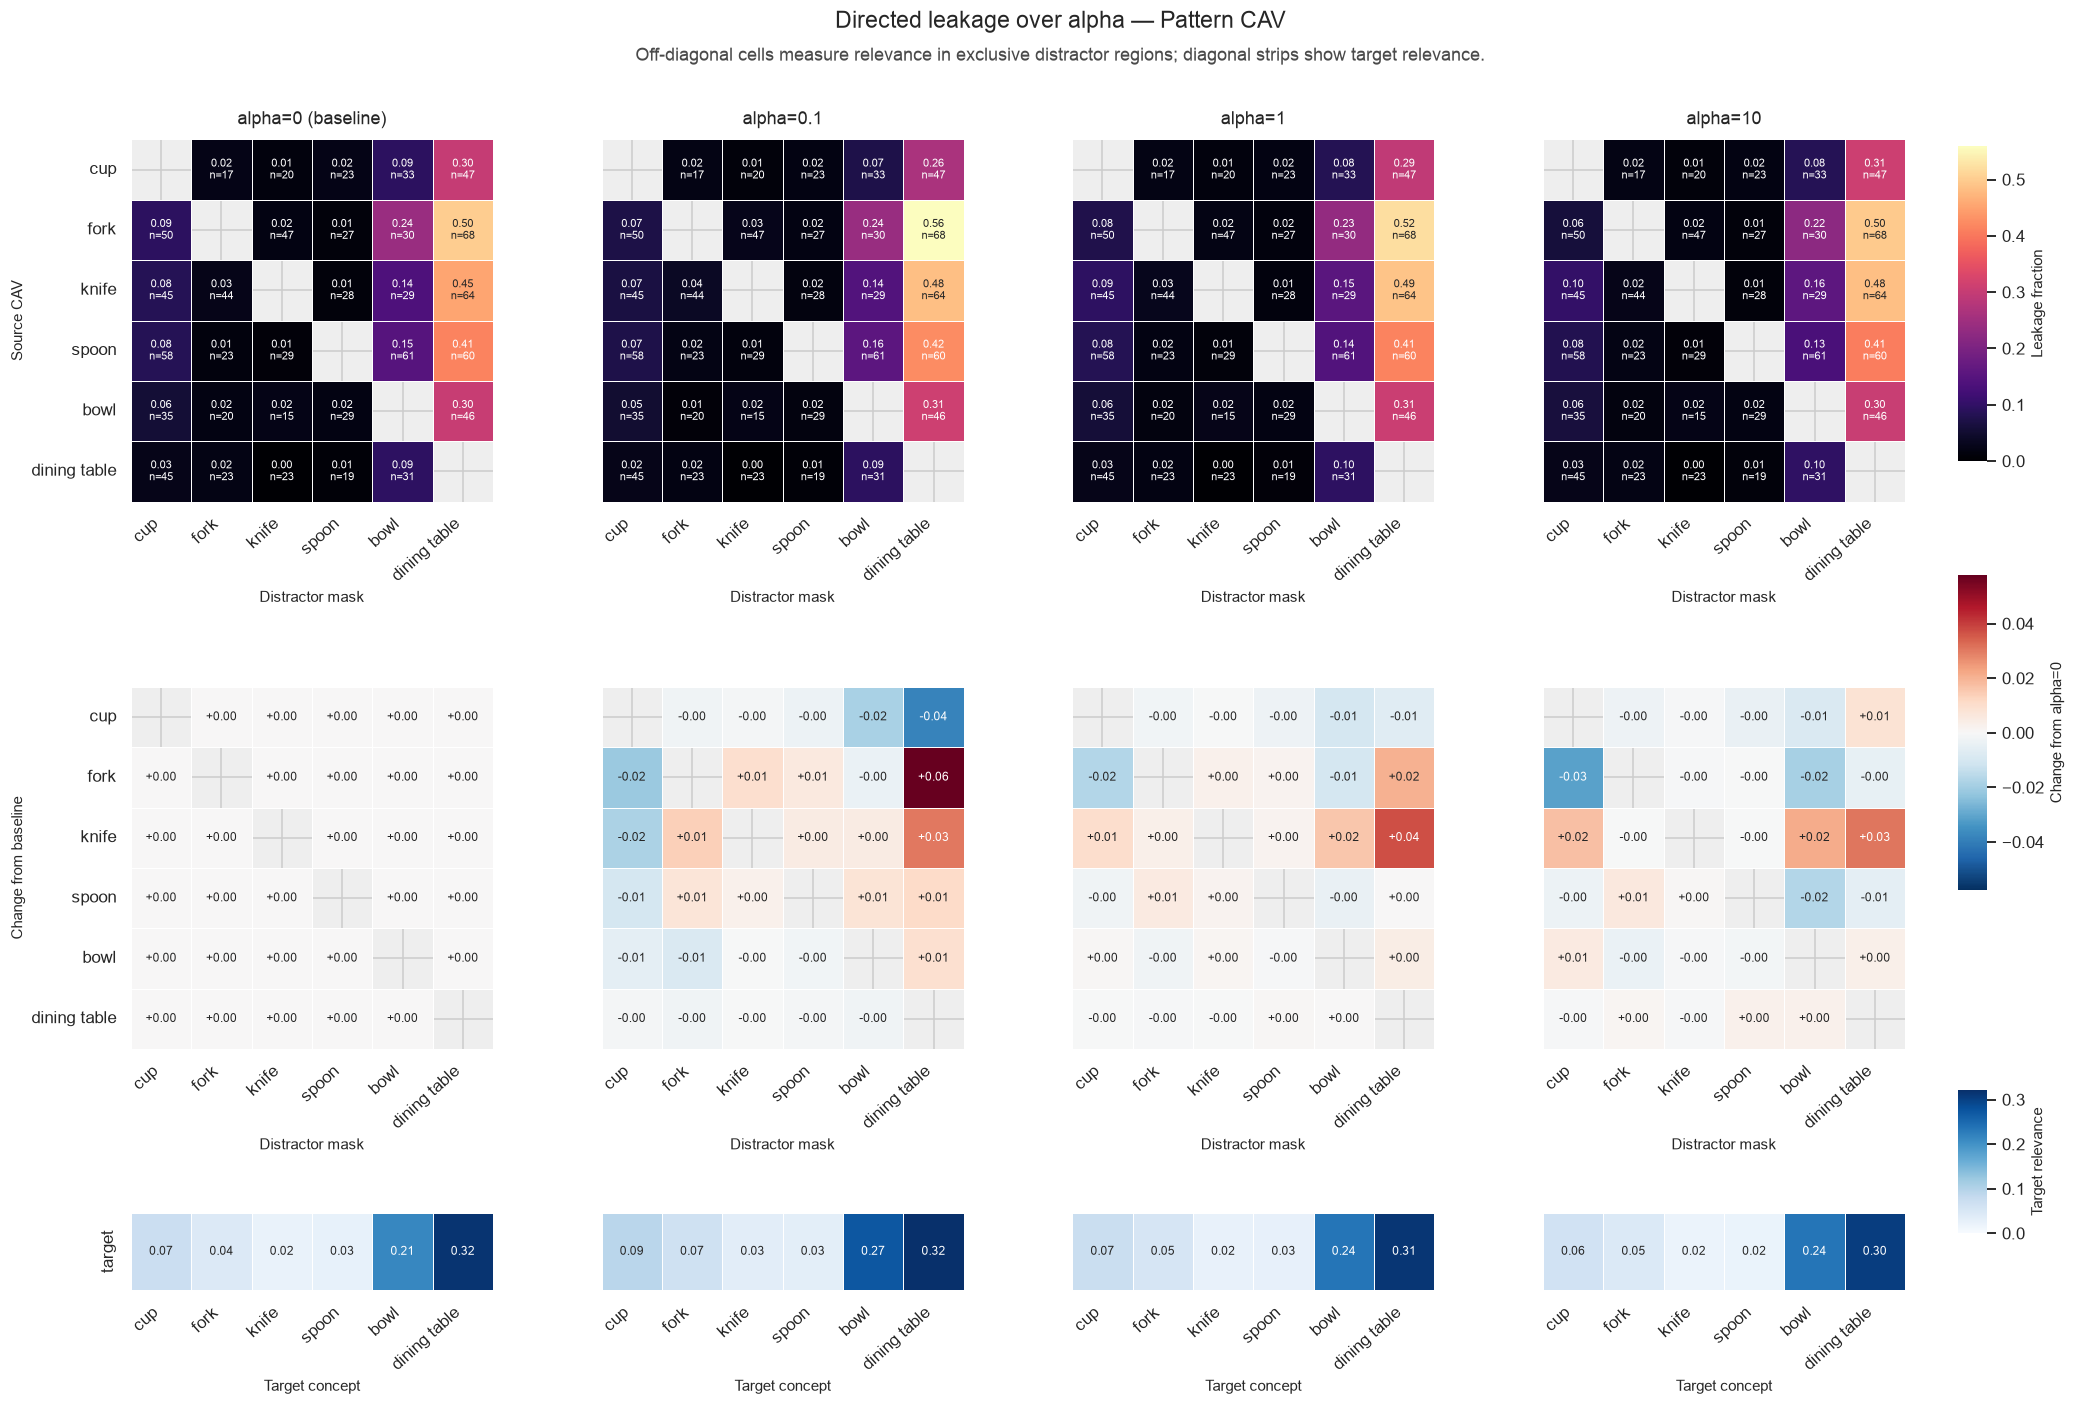

In [6]:
def plot_directed_leakage_matrices(
    cav_type: str = PRIMARY_CAV_TYPE,
    alphas: Sequence[float] = ALPHAS,
) -> plt.Figure:
    matrices = {
        alpha: load_square_csv(cav_type, alpha, "leakage_matrix.csv").astype(float)
        for alpha in alphas
    }
    counts = {
        alpha: load_square_csv(cav_type, alpha, "leakage_counts.csv")
        .fillna(0)
        .astype(int)
        for alpha in alphas
    }
    baseline = matrices[0.0]
    diagonal_mask = np.eye(len(CONCEPT_ORDER), dtype=bool)

    absolute_values = np.concatenate(
        [matrix.to_numpy()[~diagonal_mask] for matrix in matrices.values()]
    )
    absolute_vmax = max(float(np.nanmax(absolute_values)), 1e-12)
    delta_values = np.concatenate([
        (matrix - baseline).to_numpy()[~diagonal_mask]
        for matrix in matrices.values()
    ])
    delta_limit = max(float(np.nanmax(np.abs(delta_values))), 1e-12)
    target_vmax = max(
        float(np.nanmax([np.diag(matrix).max() for matrix in matrices.values()])),
        1e-12,
    )

    figure = plt.figure(figsize=(4.8 * len(alphas), 13.0))
    grid = GridSpec(
        3,
        len(alphas),
        figure=figure,
        height_ratios=[6, 6, 1.15],
        hspace=0.48,
        wspace=0.30,
    )
    absolute_cbar = figure.add_axes([0.925, 0.66, 0.014, 0.22])
    delta_cbar = figure.add_axes([0.925, 0.36, 0.014, 0.22])
    target_cbar = figure.add_axes([0.925, 0.12, 0.014, 0.10])

    for column, alpha in enumerate(alphas):
        matrix = matrices[alpha]
        support = counts[alpha]
        unsupported = support.to_numpy() == 0
        mask = diagonal_mask | unsupported | ~np.isfinite(matrix.to_numpy())

        annotations = np.empty(matrix.shape, dtype=object)
        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                annotations[row, col] = (
                    ""
                    if mask[row, col]
                    else f"{matrix.iat[row, col]:.2f}\nn={support.iat[row, col]}"
                )

        absolute_axis = figure.add_subplot(grid[0, column])
        sns.heatmap(
            matrix,
            mask=mask,
            annot=annotations,
            fmt="",
            cmap="magma",
            vmin=0,
            vmax=absolute_vmax,
            square=True,
            linewidths=0.4,
            linecolor="white",
            cbar=column == len(alphas) - 1,
            cbar_ax=absolute_cbar if column == len(alphas) - 1 else None,
            cbar_kws={"label": "Leakage fraction"},
            annot_kws={"fontsize": 7},
            ax=absolute_axis,
        )
        absolute_axis.set_facecolor("#EEEEEE")
        absolute_axis.set_title(alpha_label(alpha), pad=10)
        absolute_axis.set_xlabel("Distractor mask")
        absolute_axis.set_ylabel("Source CAV" if column == 0 else "")
        absolute_axis.set_xticklabels(
            absolute_axis.get_xticklabels(), rotation=42, ha="right"
        )
        if column > 0:
            absolute_axis.set_yticklabels([])

        delta = matrix - baseline
        delta_annotations = np.empty(delta.shape, dtype=object)
        for row in range(delta.shape[0]):
            for col in range(delta.shape[1]):
                delta_annotations[row, col] = (
                    "" if mask[row, col] else f"{delta.iat[row, col]:+.2f}"
                )

        delta_axis = figure.add_subplot(grid[1, column])
        sns.heatmap(
            delta,
            mask=mask,
            annot=delta_annotations,
            fmt="",
            cmap="RdBu_r",
            vmin=-delta_limit,
            vmax=delta_limit,
            center=0,
            square=True,
            linewidths=0.4,
            linecolor="white",
            cbar=column == len(alphas) - 1,
            cbar_ax=delta_cbar if column == len(alphas) - 1 else None,
            cbar_kws={"label": "Change from alpha=0"},
            annot_kws={"fontsize": 8},
            ax=delta_axis,
        )
        delta_axis.set_facecolor("#EEEEEE")
        delta_axis.set_xlabel("Distractor mask")
        delta_axis.set_ylabel("Change from baseline" if column == 0 else "")
        delta_axis.set_xticklabels(
            delta_axis.get_xticklabels(), rotation=42, ha="right"
        )
        if column > 0:
            delta_axis.set_yticklabels([])

        target_values = np.diag(matrix).reshape(1, -1)
        target_annotations = np.array(
            [[f"{value:.2f}" for value in target_values[0]]],
            dtype=object,
        )
        target_axis = figure.add_subplot(grid[2, column])
        sns.heatmap(
            target_values,
            annot=target_annotations,
            fmt="",
            cmap="Blues",
            vmin=0,
            vmax=target_vmax,
            linewidths=0.4,
            linecolor="white",
            cbar=column == len(alphas) - 1,
            cbar_ax=target_cbar if column == len(alphas) - 1 else None,
            cbar_kws={"label": "Target relevance"},
            xticklabels=CONCEPT_ORDER,
            yticklabels=["target"],
            annot_kws={"fontsize": 8},
            ax=target_axis,
        )
        target_axis.set_xlabel("Target concept")
        target_axis.set_ylabel("")
        target_axis.set_xticklabels(
            target_axis.get_xticklabels(), rotation=42, ha="right"
        )
        if column > 0:
            target_axis.set_yticklabels([])

    figure.suptitle(
        f"Directed leakage over alpha — {CAV_LABELS.get(cav_type, cav_type)} CAV",
        fontsize=15,
        y=0.975,
    )
    figure.text(
        0.5,
        0.94,
        "Off-diagonal cells measure relevance in exclusive distractor regions; "
        "diagonal strips show target relevance.",
        ha="center",
        color="#4A4A4A",
    )
    figure.subplots_adjust(left=0.06, right=0.90, top=0.90, bottom=0.08)
    return finish_figure(
        figure,
        f"figure_3_leakage_matrices_{MODEL_LAYER}_{cav_type}",
    )


LEAKAGE_MATRIX_FIGURE = plot_directed_leakage_matrices()


## Figure 4 — Alpha-response curves

The two aligned panels show how target relevance and off-diagonal leakage change across the ordered alpha settings. Each line is one CAV method, and the shaded alpha = 0 column identifies the non-orthogonalized baseline. This makes the localization–leakage trade-off visible without combining two scales on one axis.


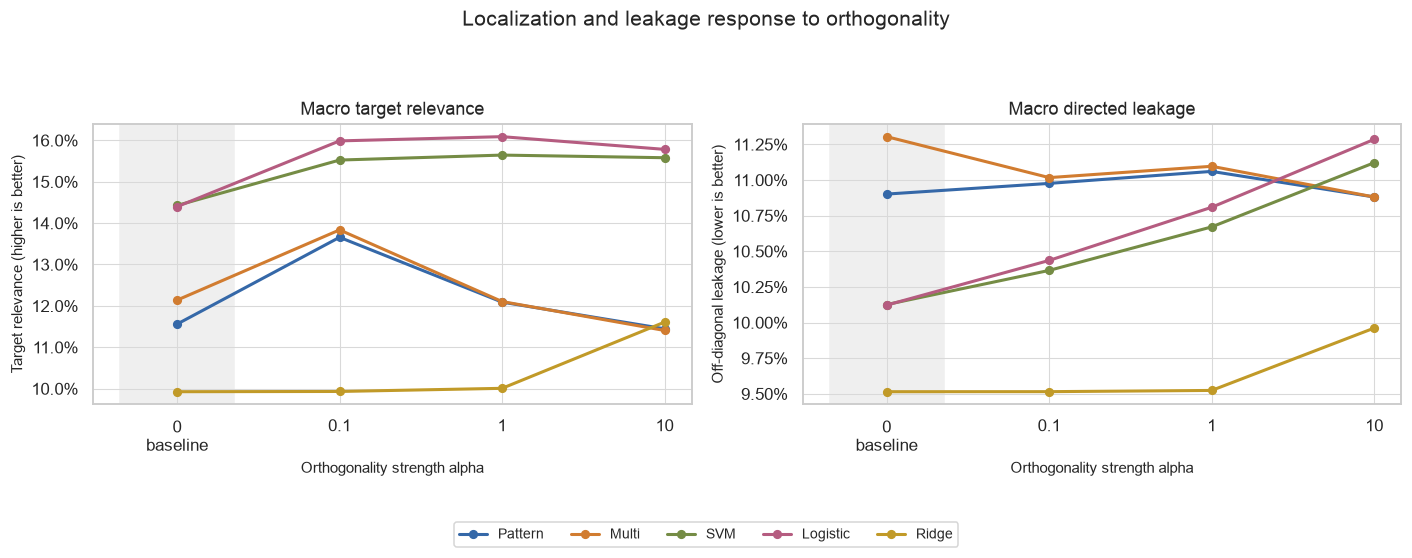

In [7]:
def plot_alpha_response(
    summary: pd.DataFrame = RUN_SUMMARY,
) -> plt.Figure:
    panels = (
        (
            "target_relevance",
            "Macro target relevance",
            "Target relevance (higher is better)",
        ),
        (
            "off_diagonal_leakage",
            "Macro directed leakage",
            "Off-diagonal leakage (lower is better)",
        ),
    )
    x_positions = np.arange(len(ALPHAS))
    alpha_to_x = {alpha: index for index, alpha in enumerate(ALPHAS)}
    figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharex=True)

    for axis, (metric, title, ylabel) in zip(axes, panels):
        axis.axvspan(-0.35, 0.35, color="#EFEFEF", zorder=0)
        for cav_type in CAV_TYPES:
            series = summary.loc[summary["cav_type"].eq(cav_type)].copy()
            if series.empty:
                continue
            series["x"] = series["alpha"].map(alpha_to_x)
            series = series.sort_values("x")
            axis.plot(
                series["x"],
                series[metric],
                marker="o",
                linewidth=2,
                markersize=5,
                color=CAV_COLORS[cav_type],
                label=CAV_LABELS[cav_type],
            )
        axis.set_title(title)
        axis.set_xlabel("Orthogonality strength alpha")
        axis.set_ylabel(ylabel)
        axis.set_xticks(x_positions, ["0\nbaseline", "0.1", "1", "10"])
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))
        axis.grid(True, color="#D9D9D9", linewidth=0.7)

    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(handles),
        bbox_to_anchor=(0.5, -0.01),
        frameon=True,
    )
    figure.suptitle(
        "Localization and leakage response to orthogonality",
        fontsize=14,
        y=1.02,
    )
    figure.tight_layout(rect=[0, 0.10, 1, 0.96])
    return finish_figure(figure, f"figure_4_alpha_response_{MODEL_LAYER}")


ALPHA_RESPONSE_FIGURE = plot_alpha_response()


## Figure 5 — Concept-level localization profile

For the selected CAV method, this faceted dot-and-error-bar figure compares the six concepts on target relevance, pointing-game accuracy, IoU, and ground-truth coverage. Each alpha is shown at a small vertical offset; alpha = 0 uses an open marker to distinguish the baseline from the orthogonalized settings. Error bars are the saved per-concept standard errors.


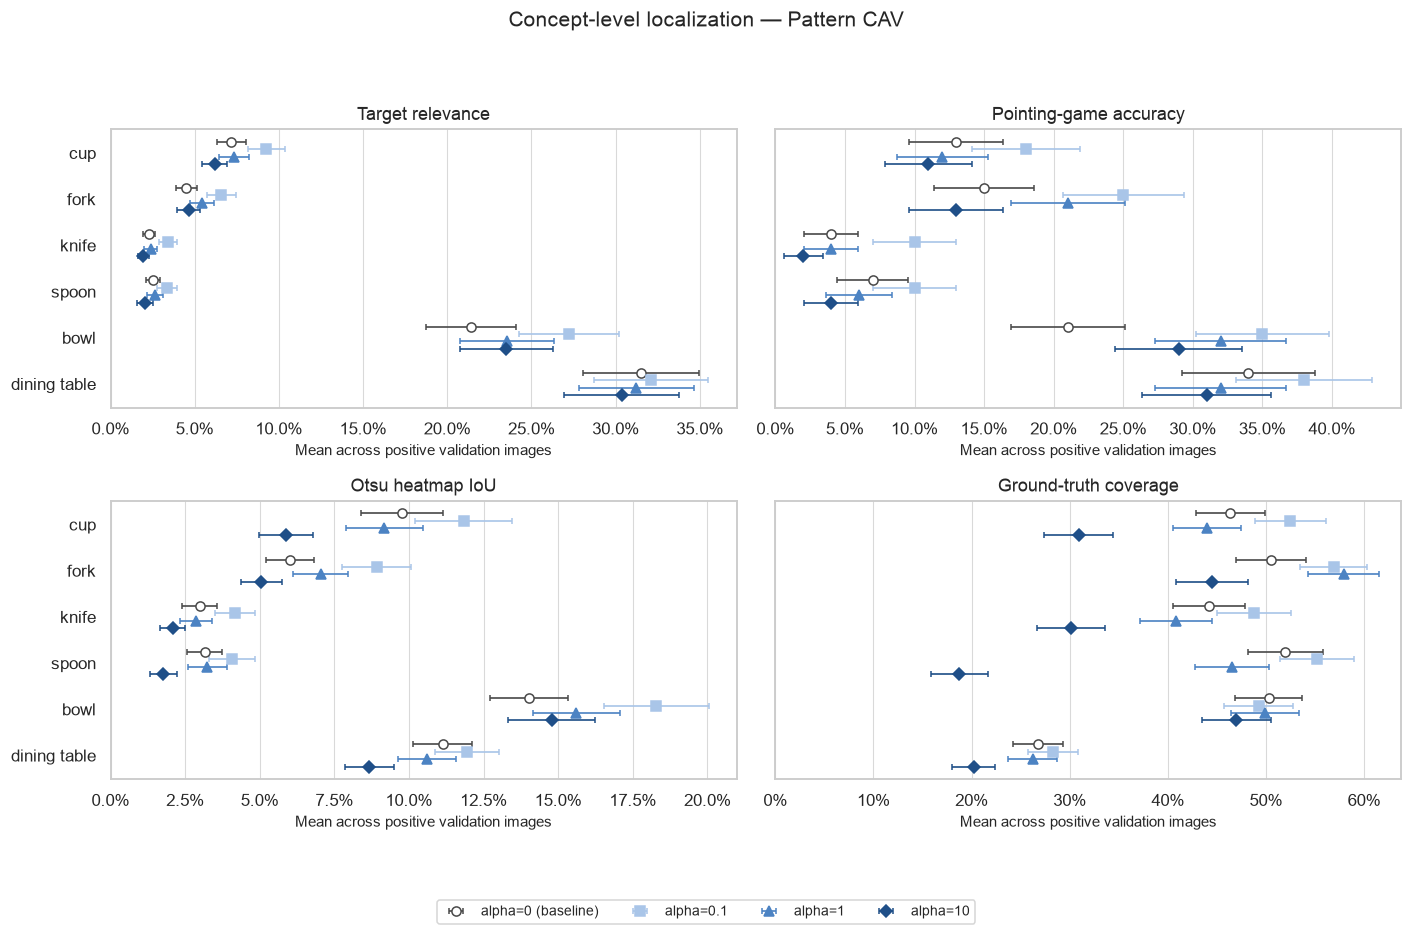

In [8]:
def plot_concept_localization_profile(
    cav_type: str = PRIMARY_CAV_TYPE,
    alphas: Sequence[float] = ALPHAS,
) -> plt.Figure:
    metric_labels = {
        "target_relevance": "Target relevance",
        "pointing_game": "Pointing-game accuracy",
        "iou": "Otsu heatmap IoU",
        "intersection_over_gt": "Ground-truth coverage",
    }
    figure, axes = plt.subplots(2, 2, figsize=(13.0, 8.2), sharey=True)
    y_positions = np.arange(len(CONCEPT_ORDER))
    offsets = np.linspace(-0.24, 0.24, len(alphas))

    for axis, (metric, title) in zip(axes.flat, metric_labels.items()):
        for offset, alpha in zip(offsets, alphas):
            series = (
                LOCALIZATION_SUMMARY.loc[
                    LOCALIZATION_SUMMARY["cav_type"].eq(cav_type)
                    & LOCALIZATION_SUMMARY["alpha"].eq(float(alpha))
                    & LOCALIZATION_SUMMARY["metric"].eq(metric)
                ]
                .set_index("concept")
                .reindex(CONCEPT_ORDER)
            )
            if series["mean"].isna().all():
                continue
            is_baseline = np.isclose(alpha, 0.0)
            color = ALPHA_COLORS[float(alpha)]
            axis.errorbar(
                series["mean"].astype(float),
                y_positions + offset,
                xerr=series["sem"].astype(float).fillna(0),
                fmt=ALPHA_MARKERS[float(alpha)],
                color=color,
                markerfacecolor="white" if is_baseline else color,
                markeredgecolor=color,
                markersize=6,
                capsize=2,
                linewidth=1.1,
                label=alpha_label(float(alpha)),
            )
        axis.set_title(title)
        axis.set_xlabel("Mean across positive validation images")
        axis.set_yticks(y_positions, CONCEPT_ORDER)
        axis.set_xlim(left=0)
        axis.xaxis.set_major_formatter(PercentFormatter(1.0))
        axis.grid(True, axis="x", color="#D9D9D9", linewidth=0.7)
        axis.grid(False, axis="y")

    axes[0, 0].invert_yaxis()
    handles, labels = axes.flat[0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(handles),
        bbox_to_anchor=(0.5, -0.01),
        frameon=True,
    )
    figure.suptitle(
        f"Concept-level localization — {CAV_LABELS.get(cav_type, cav_type)} CAV",
        fontsize=14,
        y=1.01,
    )
    figure.tight_layout(rect=[0, 0.08, 1, 0.97])
    return finish_figure(
        figure,
        f"figure_5_concept_profile_{MODEL_LAYER}_{cav_type}",
    )


CONCEPT_PROFILE_FIGURE = plot_concept_localization_profile()


## Figure 6 — Matched qualitative localization grid

The same deterministic validation image is shown for each concept across alpha = 0, 0.1, 1, and 10 for the selected CAV method. Every saved panel contains the input image, positive-relevance heatmap, union ground-truth mask, and heatmap overlay. Matching filenames across columns prevents sample selection from being confused with an alpha effect.


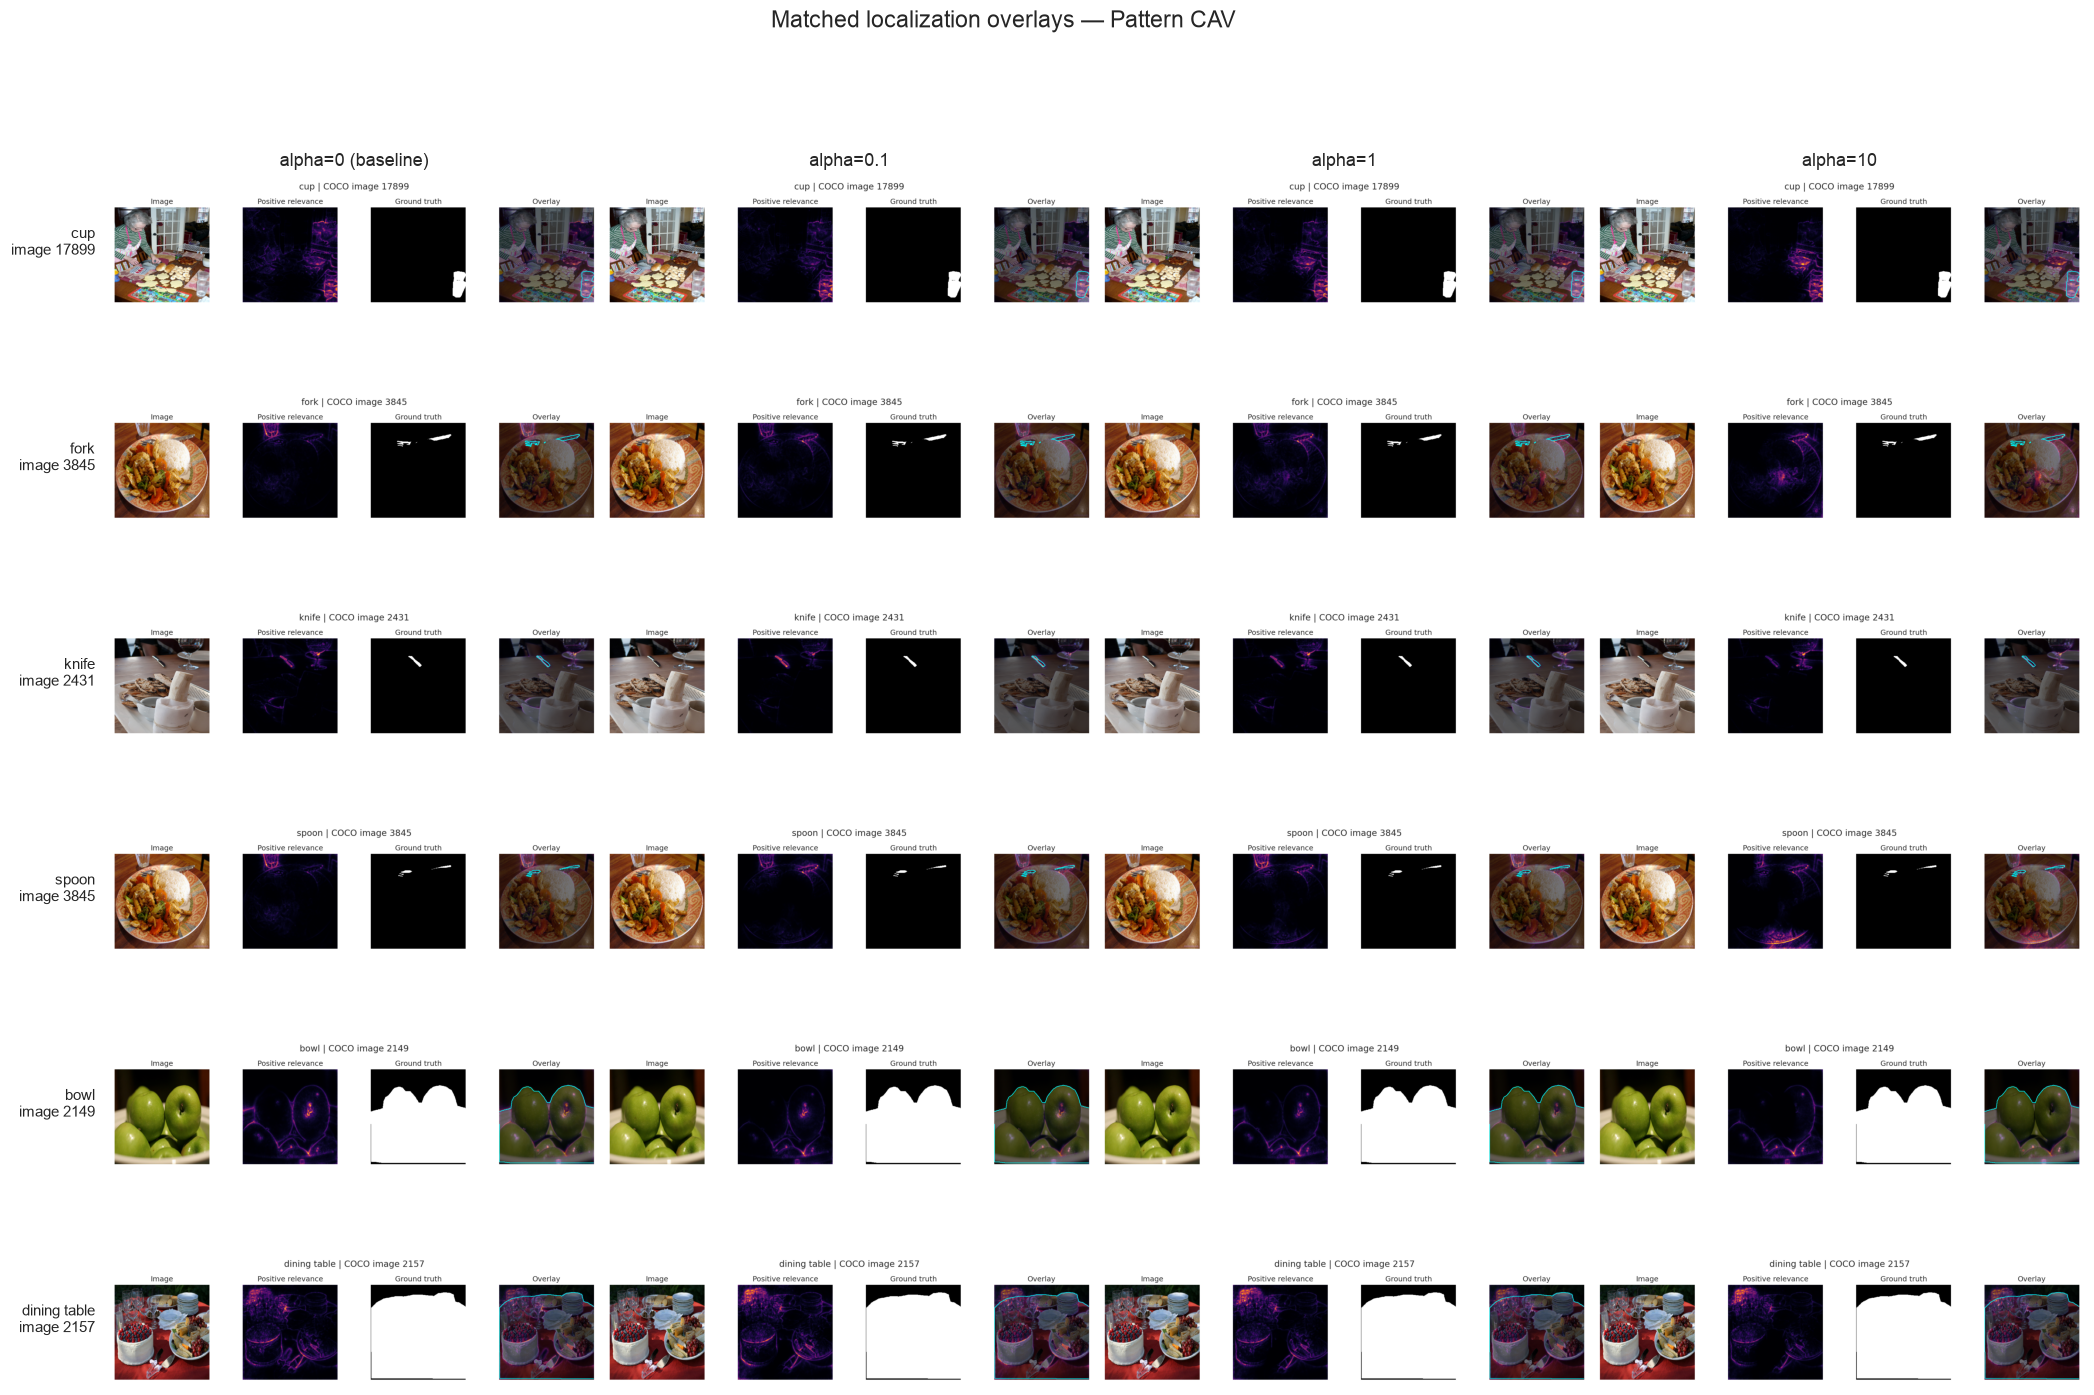

In [9]:
def _overlay_directory(cav_type: str, alpha: float) -> Path:
    return get_run_dir(cav_type, alpha) / "media" / "localization"


def _overlay_image_id(filename: str) -> int:
    return int(Path(filename).stem.rsplit("_", 1)[-1])


def plot_matched_localization_overlays(
    cav_type: str = PRIMARY_CAV_TYPE,
    alphas: Sequence[float] = ALPHAS,
    concepts: Sequence[str] = CONCEPT_ORDER,
) -> plt.Figure:
    name_sets = [
        {path.name for path in _overlay_directory(cav_type, alpha).glob("*.png")}
        for alpha in alphas
    ]
    common_names = set.intersection(*name_sets)
    if not common_names:
        raise FileNotFoundError(
            "No localization overlay filenames are shared across the requested alpha settings."
        )

    selected = []
    for concept in concepts:
        concept_token = f"_{concept.replace(' ', '-')}_"
        matches = sorted(
            (name for name in common_names if concept_token in name),
            key=_overlay_image_id,
        )
        if not matches:
            warnings.warn(f"No matched overlay found for concept {concept!r}.")
            continue
        selected.append((concept, matches[0]))

    if not selected:
        raise FileNotFoundError("No requested concept has a matched localization overlay.")

    figure, axes = plt.subplots(
        len(selected),
        len(alphas),
        figsize=(5.0 * len(alphas), 2.25 * len(selected)),
        squeeze=False,
    )
    for row, (concept, filename) in enumerate(selected):
        image_id = _overlay_image_id(filename)
        for column, alpha in enumerate(alphas):
            axis = axes[row, column]
            image_path = _overlay_directory(cav_type, alpha) / filename
            with Image.open(image_path) as image:
                axis.imshow(np.asarray(image.convert("RGB")))
            axis.set_xticks([])
            axis.set_yticks([])
            for spine in axis.spines.values():
                spine.set_visible(False)
            if row == 0:
                axis.set_title(alpha_label(float(alpha)), pad=8)
            if column == 0:
                axis.set_ylabel(
                    f"{concept}\nimage {image_id}",
                    rotation=0,
                    ha="right",
                    va="center",
                    labelpad=10,
                )

    figure.suptitle(
        f"Matched localization overlays — {CAV_LABELS.get(cav_type, cav_type)} CAV",
        fontsize=15,
        y=0.995,
    )
    figure.tight_layout(rect=[0.04, 0.01, 1, 0.97], h_pad=0.8, w_pad=0.4)
    return finish_figure(
        figure,
        f"figure_6_matched_overlays_{MODEL_LAYER}_{cav_type}",
    )


QUALITATIVE_FIGURE = plot_matched_localization_overlays()
